# PathFormer Doppler Motion Demo

This notebook is a **small concept demo** for the dynamics question we discussed.

The main idea is to show that even in a static DeepMIMO scene, once we impose **user motion** and **sequential Doppler evolution**, the final channel at location `c` is no longer identical to a purely static channel computed only from geometry at `c`.

So the comparison is:
- `H_static(c)`: static channel at the final location `c`
- `H_dyn(c | a->b->c)`: channel obtained by evolving the state sequentially along the trajectory
- `H_prior(b)`: a stale quasi-static prior from the previous location `b`

This is exactly the type of setup where a static PathFormer prior can still be useful, but is **not** an oracle.


In [1]:
import os
import warnings
from pathlib import Path

import deepmimo as dm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.chdir('/home/blessedg/Pathformer')
warnings.filterwarnings('ignore', category=UserWarning)

PROJECT_ROOT = Path('/home/blessedg/Pathformer')
PROJECT_ROOT


PosixPath('/home/blessedg/Pathformer')

## Configuration

This demo uses one static scenario and builds a short trajectory from neighboring RX points.

We keep the model deliberately simple:
- one transmitter
- one 3-step path `a -> b -> c`
- a user velocity vector
- per-step Doppler phase evolution on the channel matrix

The goal here is intuition, not a production-grade channel simulator.


In [2]:
SCENARIO = 'city_23_beijing_3p5'
TX_INDEX = 0
TARGET_USER_INDEX = 1000
HISTORY_LEN = 23   # gives a -> b -> c
DT_SECONDS = 0.5*1e-6
USER_VELOCITY_MPS = np.array([5.0, 0.0, 0.0], dtype=np.float32)
v = 3000


# DOPPLER_HZ = 100.0
DOPPLER_HZ = (v/(3*10e8)) * (3.5e9)

USE_PATH_POWER_SORT = True

print('scenario:', SCENARIO)
print('tx_index:', TX_INDEX)
print('target_user_index:', TARGET_USER_INDEX)
print('dt_seconds:', DT_SECONDS)
print('user_velocity_mps:', USER_VELOCITY_MPS)
print('doppler_hz:', DOPPLER_HZ)


scenario: city_23_beijing_3p5
tx_index: 0
target_user_index: 1000
dt_seconds: 5e-07
user_velocity_mps: [5. 0. 0.]
doppler_hz: 3500.0


In [3]:
dataset = dm.load(SCENARIO)
plot_dataset = dataset[0] if isinstance(dataset, list) else dataset
plot_dataset.keys()


Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 85988)


dict_keys(['aoa_az', 'aoa_el', 'aod_az', 'aod_el', 'power', 'phase', 'delay', 'rx_pos', 'tx_pos', 'inter', 'inter_pos', 'txrx', 'load_params', 'name', 'rt_params', 'scene', 'materials'])

In [4]:
def _as_pos_2d(values):
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        return values.reshape(1, -1)
    return values.reshape(-1, values.shape[-1])


def squeeze_channel_to_matrix(channel):
    channel = np.asarray(channel).squeeze(0)
    if channel.ndim != 2:
        raise ValueError(f'Expected 2D channel after squeeze, got shape {channel.shape}')
    return channel.astype(np.complex64, copy=False)


def get_direction_candidates(rx_pos, user_pos, direction, duration):
    x_vals = rx_pos[:, 0]
    y_vals = rx_pos[:, 1]
    user_x = user_pos[0]
    user_y = user_pos[1]

    if direction == 'left':
        mask = np.isclose(y_vals, user_y) & (x_vals < user_x)
        candidates = np.where(mask)[0]
        order = np.argsort(x_vals[candidates])
        ordered = candidates[order]
        return ordered[-duration:]
    if direction == 'right':
        mask = np.isclose(y_vals, user_y) & (x_vals > user_x)
        candidates = np.where(mask)[0]
        order = np.argsort(-x_vals[candidates])
        ordered = candidates[order]
        return ordered[:duration]
    if direction == 'down':
        mask = np.isclose(x_vals, user_x) & (y_vals < user_y)
        candidates = np.where(mask)[0]
        order = np.argsort(y_vals[candidates])
        ordered = candidates[order]
        return ordered[-duration:]
    if direction == 'up':
        mask = np.isclose(x_vals, user_x) & (y_vals > user_y)
        candidates = np.where(mask)[0]
        order = np.argsort(-y_vals[candidates])
        ordered = candidates[order]
        return ordered[:duration]
    raise ValueError(f'Unknown direction: {direction}')


def pick_history_indices(rx_pos, user_idx, duration):
    user_pos = rx_pos[user_idx]
    directions = ['left', 'right', 'down', 'up']

    best_direction = None
    best_candidates = np.array([], dtype=np.int64)
    for direction in directions:
        candidates = get_direction_candidates(rx_pos, user_pos, direction, duration)
        if candidates.size >= duration:
            history = candidates[-duration:] if direction in {'left', 'down'} else candidates[:duration]
            return history.astype(np.int64, copy=False), direction, True
        if candidates.size > best_candidates.size:
            best_candidates = candidates
            best_direction = direction

    if best_candidates.size == 0:
        return None, 'self', False
    return None, best_direction, False


def build_trajectory(ds, user_idx, history_len=2):
    rx_pos = np.asarray(ds.rx_pos)
    history_indices, direction, is_valid = pick_history_indices(rx_pos, user_idx, history_len)
    if not is_valid:
        raise ValueError(f'Could not build a valid history of length {history_len} for user {user_idx}.')
    ordered = list(history_indices.astype(int)) + [int(user_idx)]
    labels = ['a', 'b', 'c'] if len(ordered) == 3 else [f't{i}' for i in range(len(ordered))]
    return ordered, labels, direction


def plot_scene_trajectory(ds, ordered_users, labels, direction):
    rx_pos = np.asarray(ds.rx_pos)
    tx_pos = _as_pos_2d(ds.tx_pos)[0]

    ax = ds.scene.plot(title=False, proj_3D=False)
    ax.scatter(tx_pos[0], tx_pos[1], marker='^', s=150, color='tab:blue', edgecolors='black', linewidths=0.6, zorder=6, label='TX')

    pts = rx_pos[ordered_users]
    ax.plot(pts[:, 0], pts[:, 1], linestyle='--', color='black', linewidth=1.2, zorder=4)
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(ordered_users)))

    trajectory_users = []
    for i, (u, label) in enumerate(zip(ordered_users, labels)):
        color = colors[i]
        ax.scatter(rx_pos[u, 0], rx_pos[u, 1], s=120, color=color, edgecolors='black', linewidths=0.6, zorder=7)
        ax.text(rx_pos[u, 0], rx_pos[u, 1], f' {label}', fontsize=10, weight='bold')
        trajectory_users.append(rx_pos[u])

    print(f"Average distance between steps: {np.mean(np.linalg.norm(np.array( trajectory_users)[1:,:2] - np.array( trajectory_users)[:-1,:2], axis= 1))} m")
    ax.set_title(f'{len(ordered_users)}-step mobility trajectory | direction: {direction}')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.legend(loc='best')
    plt.tight_layout()
    return ax


ordered_users: [np.int64(977), np.int64(978), np.int64(979), np.int64(980), np.int64(981), np.int64(982), np.int64(983), np.int64(984), np.int64(985), np.int64(986), np.int64(987), np.int64(988), np.int64(989), np.int64(990), np.int64(991), np.int64(992), np.int64(993), np.int64(994), np.int64(995), np.int64(996), np.int64(997), np.int64(998), np.int64(999), 1000]
labels: ['t0', 't1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9', 't10', 't11', 't12', 't13', 't14', 't15', 't16', 't17', 't18', 't19', 't20', 't21', 't22', 't23']
direction: left
Average distance between steps: 1.0 m


<Axes: title={'center': '24-step mobility trajectory | direction: left'}, xlabel='x (m)', ylabel='y (m)'>

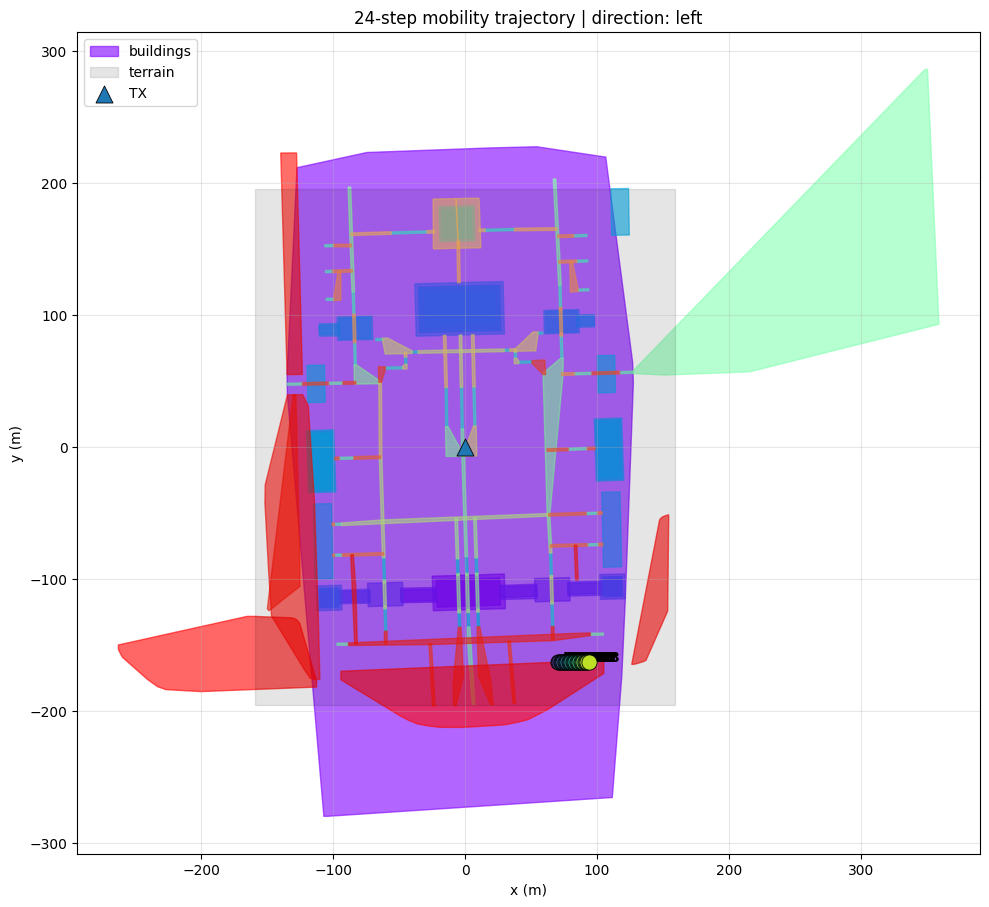

In [5]:
ordered_users, labels, direction = build_trajectory(plot_dataset, TARGET_USER_INDEX, history_len=HISTORY_LEN)
print('ordered_users:', ordered_users)
print('labels:', labels)
print('direction:', direction)
plot_scene_trajectory(plot_dataset, ordered_users, labels,direction)


## Static channels at a, b, c

These are still **static** channels from DeepMIMO. The dynamic effect comes in the next step, where we apply sequential phase evolution over time.


In [6]:
ch_params = dm.ChannelParameters()
ch_params.shape = np.array([])
plot_dataset.compute_channels(ch_params)

channels = np.asarray(plot_dataset.channels)
H_static_steps = [squeeze_channel_to_matrix(channels[user_idx]) for user_idx in ordered_users]
H_dynamic_steps = []
for step_idx, H_static in enumerate(H_static_steps):
    H_dynamic_steps.append(apply_scalar_doppler(H_static, DOPPLER_HZ, DT_SECONDS, step_idx=step_idx))

H_final_static = H_static_steps[-1]
H_final_dynamic = H_dynamic_steps[-1]
H_prior_from_prev = H_static_steps[-2] if len(H_static_steps) > 1 else H_static_steps[-1]

print('num_steps:', len(H_static_steps))
print('single channel shape:', H_final_static.shape)


The following parameters seem unnecessary:
{'shape'}
No doppler in channel generation because all velocities are zero


Generating channels: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 85988/85988 [00:02<00:00, 37941.67it/s]


NameError: name 'apply_scalar_doppler' is not defined

## Sequential dynamic evolution

This is a deliberately simple model.

We use a per-step Doppler phase rotation:

$$H_{t+1}^{dyn} = H_{t+1}^{static} \odot e^{j 2\pi f_D \Delta t (t+1)}$$

The important point is not the exact physics of every path here. The point is to show that once time accumulates across `a -> b -> c`, the final instantaneous channel differs from a static channel at `c`.

We also compare against a stale quasi-static prior from `b`, which is closer to how a PathFormer prior would be used in a dynamic setting.


In [ ]:
def scalar_doppler_phase(doppler_hz, dt_seconds, step_idx):
    return np.exp(1j * 2 * np.pi * doppler_hz * dt_seconds * step_idx).astype(np.complex64)


def apply_scalar_doppler(H_static, doppler_hz, dt_seconds, step_idx):
    return H_static * scalar_doppler_phase(doppler_hz, dt_seconds, step_idx)


for step_idx, step_name in enumerate(labels):
    print(f'phase({step_name}):', scalar_doppler_phase(DOPPLER_HZ, DT_SECONDS, step_idx))


phase(t0): (1+0j)
phase(t1): (0.99993956+0.010995353j)
phase(t2): (0.9997582+0.021989375j)
phase(t3): (0.999456+0.03298074j)
phase(t4): (0.9990329+0.04396812j)
phase(t5): (0.9984891+0.05495018j)
phase(t6): (0.99782455+0.0659256j)
phase(t7): (0.9970393+0.07689305j)
phase(t8): (0.9961336+0.0878512j)
phase(t9): (0.9951074+0.09879873j)
phase(t10): (0.993961+0.10973431j)
phase(t11): (0.9926943+0.12065663j)
phase(t12): (0.9913076+0.13156436j)
phase(t13): (0.9898011+0.14245619j)
phase(t14): (0.9881749+0.15333079j)
phase(t15): (0.9864293+0.16418685j)
phase(t16): (0.98456436+0.17502306j)
phase(t17): (0.98258036+0.18583812j)
phase(t18): (0.98047763+0.1966307j)
phase(t19): (0.97825634+0.2073995j)
phase(t20): (0.97591674+0.21814324j)
phase(t21): (0.9734592+0.2288606j)
phase(t22): (0.97088397+0.23955029j)
phase(t23): (0.9681913+0.25021103j)


## Channel evolution across the trajectory

This plot summarizes how the channel evolves over the full `HISTORY_LEN + 1` steps.

We track:
- mean channel magnitude at each step
- mean channel phase at each step
- step-to-step relative change in Frobenius norm


In [117]:
step_names = labels if len(labels) == len(H_dynamic_steps) else [f't{i}' for i in range(len(H_dynamic_steps))]


def fro_rel_change(current, previous):
    num = np.linalg.norm(current - previous)
    den = np.linalg.norm(previous) + 1e-12
    return float(num / den)


evolution_rows = []
for idx, (name, Hs, Hd) in enumerate(zip(step_names, H_static_steps, H_dynamic_steps)):
    row = {
        'step_index': idx,
        'step_name': name,
        'static_mean_mag': float(np.mean(np.abs(Hs))),
        'dynamic_mean_mag': float(np.mean(np.abs(Hd))),
        'static_mean_phase_deg': float(np.mean(np.angle(Hs)) * 180.0 / np.pi),
        'dynamic_mean_phase_deg': float(np.mean(np.angle(Hd)) * 180.0 / np.pi),
        'nmse_static_vs_dynamic': nmse(Hd, Hs),
        'fro_change_from_prev_dynamic': np.nan if idx == 0 else fro_rel_change(Hd, H_dynamic_steps[idx - 1]),
    }
    evolution_rows.append(row)

evolution_df = pd.DataFrame(evolution_rows)
evolution_df


,step_index,step_name,static_mean_mag,dynamic_mean_mag,static_mean_phase_deg,dynamic_mean_phase_deg,nmse_static_vs_dynamic,fro_change_from_prev_dynamic
0,0,t0,4.541023e-08,4.541023e-08,-26.853205,-26.853205,0.000000e+00,NaN
1,1,t1,4.581632e-08,4.581632e-08,16.296309,16.926311,1.996905e-06,1.847735
2,2,t2,4.644168e-08,4.644168e-08,-5.437681,-4.177683,8.203056e-06,1.687855
3,3,t3,7.507451e-08,7.507451e-08,-3.064244,-46.174244,4.694256e-05,1.945205
4,4,t4,2.694798e-08,2.694798e-08,-16.167622,-13.647622,1.117178e-05,1.351918
5,5,t5,3.369952e-10,3.369952e-10,0.086217,3.236218,3.396084e-09,0.998956
6,6,t6,2.053093e-09,2.053093e-09,-0.069990,3.710008,1.472590e-07,5.568449
7,7,t7,2.018210e-09,2.018210e-09,11.992348,16.402348,1.943450e-07,1.548731
8,8,t8,2.014478e-09,2.014478e-09,8.372609,13.412609,2.520404e-07,1.373996
9,9,t9,2.651379e-10,2.651379e-10,-22.929586,-17.259588,5.505971e-09,1.009775


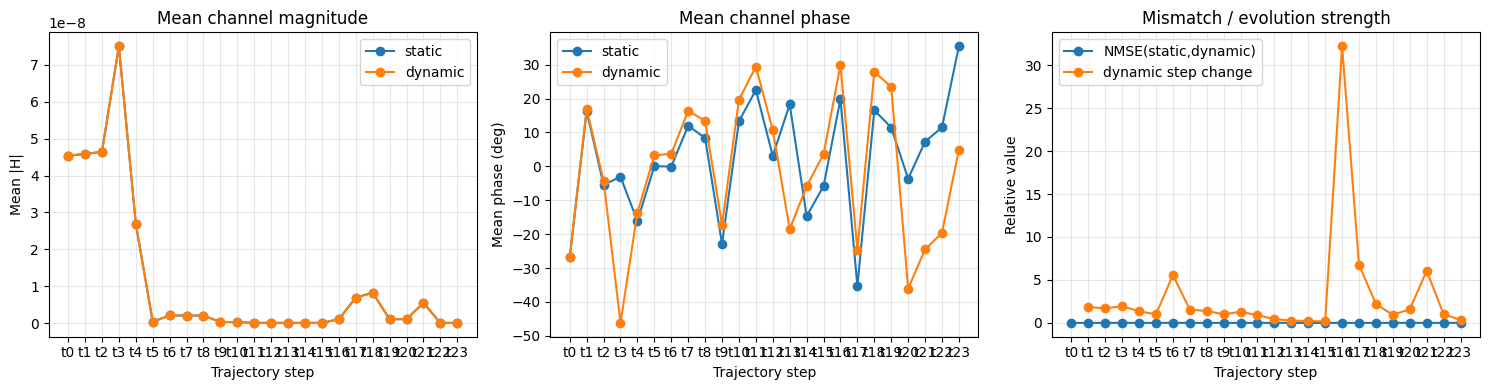

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(evolution_df['step_name'], evolution_df['static_mean_mag'], marker='o', label='static')
axes[0].plot(evolution_df['step_name'], evolution_df['dynamic_mean_mag'], marker='o', label='dynamic')
axes[0].set_title('Mean channel magnitude')
axes[0].set_xlabel('Trajectory step')
axes[0].set_ylabel('Mean |H|')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(evolution_df['step_name'], evolution_df['static_mean_phase_deg'], marker='o', label='static')
axes[1].plot(evolution_df['step_name'], evolution_df['dynamic_mean_phase_deg'], marker='o', label='dynamic')
axes[1].set_title('Mean channel phase')
axes[1].set_xlabel('Trajectory step')
axes[1].set_ylabel('Mean phase (deg)')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(evolution_df['step_name'], evolution_df['nmse_static_vs_dynamic'], marker='o', label='NMSE(static,dynamic)')
axes[2].plot(evolution_df['step_name'], evolution_df['fro_change_from_prev_dynamic'], marker='o', label='dynamic step change')
axes[2].set_title('Mismatch / evolution strength')
axes[2].set_xlabel('Trajectory step')
axes[2].set_ylabel('Relative value')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


In [119]:
DOPPLER_HZ

3500.0

## Compare static vs dynamic vs stale prior

We compare magnitude and phase differences.

In a real experiment, the PathFormer prior would be more structured than just `H_b`, but this is enough to illustrate the mismatch you care about.


In [7]:
def nmse(reference, estimate):
    num = np.sum(np.abs(reference - estimate) ** 2)
    den = np.sum(np.abs(reference) ** 2) + 1e-12
    return float(num / den)


def phase_mae_deg(reference, estimate):
    delta = np.angle(estimate) - np.angle(reference)
    delta = (delta + np.pi) % (2 * np.pi) - np.pi
    return float(np.mean(np.abs(delta)) * 180.0 / np.pi)


final_label = step_names[-1]
prev_label = step_names[-2] if len(step_names) > 1 else step_names[-1]
metrics = pd.DataFrame([
    {
        'comparison': f'static_{final_label} vs dynamic_{final_label}',
        'nmse': nmse(H_final_dynamic, H_final_static),
        'phase_mae_deg': phase_mae_deg(H_final_dynamic, H_final_static),
    },
    {
        'comparison': f'prior_{prev_label} vs dynamic_{final_label}',
        'nmse': nmse(H_final_dynamic, H_prior_from_prev),
        'phase_mae_deg': phase_mae_deg(H_final_dynamic, H_prior_from_prev),
    },
    {
        'comparison': f'static_{final_label} vs prior_{prev_label}',
        'nmse': nmse(H_prior_from_prev, H_final_static),
        'phase_mae_deg': phase_mae_deg(H_prior_from_prev, H_final_static),
    },
])
metrics


NameError: name 'step_names' is not defined

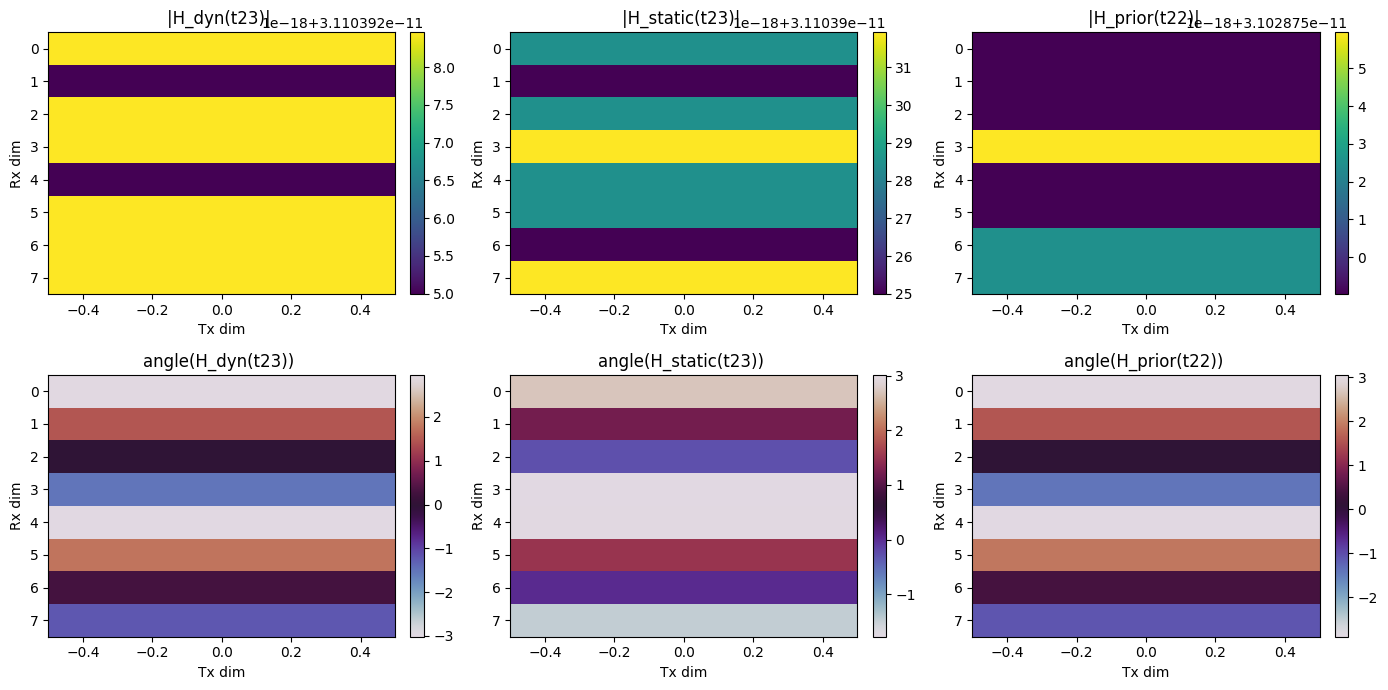

In [128]:
def plot_channel_triplet(H_ref, H_static, H_prior, final_label='c', prior_label='b', title_suffix=''):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))

    mats = [
        (np.abs(H_ref), f'|H_dyn({final_label})| {title_suffix}'),
        (np.abs(H_static), f'|H_static({final_label})| {title_suffix}'),
        (np.abs(H_prior), f'|H_prior({prior_label})| {title_suffix}'),
        (np.angle(H_ref), f'angle(H_dyn({final_label})) {title_suffix}'),
        (np.angle(H_static), f'angle(H_static({final_label})) {title_suffix}'),
        (np.angle(H_prior), f'angle(H_prior({prior_label})) {title_suffix}'),
    ]

    cmaps = ['viridis', 'viridis', 'viridis', 'twilight', 'twilight', 'twilight']
    for ax, (mat, title), cmap in zip(axes.flat, mats, cmaps):
        im = ax.imshow(mat, aspect='auto', cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel('Tx dim')
        ax.set_ylabel('Rx dim')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


plot_channel_triplet(H_final_dynamic, H_final_static, H_prior_from_prev, final_label=final_label, prior_label=prev_label)


## Add noisy observation of the dynamic channel

This mimics the idea that the estimator does not observe the clean dynamic channel directly.

We add complex Gaussian noise at a configurable SNR and then compare:
- clean dynamic target
- noisy dynamic observation
- static final channel
- stale prior from the previous step


In [129]:
NOISY_OBS_SNR_DB = 20.0
print('NOISY_OBS_SNR_DB:', NOISY_OBS_SNR_DB)


NOISY_OBS_SNR_DB: 20.0


In [130]:
def add_complex_awgn(signal, snr_db, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    signal = np.asarray(signal, dtype=np.complex64)
    signal_power = np.mean(np.abs(signal) ** 2)
    snr_linear = 10 ** (snr_db / 10.0)
    noise_power = signal_power / max(snr_linear, 1e-12)
    noise_std = np.sqrt(noise_power / 2.0)
    noise = noise_std * (
        rng.standard_normal(signal.shape) + 1j * rng.standard_normal(signal.shape)
    )
    return (signal + noise).astype(np.complex64)


H_noisy_dynamic = add_complex_awgn(H_final_dynamic, NOISY_OBS_SNR_DB)

noise_metrics = pd.DataFrame([
    {
        'comparison': f'noisy_dynamic_{final_label} vs dynamic_{final_label}',
        'nmse': nmse(H_final_dynamic, H_noisy_dynamic),
        'phase_mae_deg': phase_mae_deg(H_final_dynamic, H_noisy_dynamic),
    },
    {
        'comparison': f'noisy_dynamic_{final_label} vs static_{final_label}',
        'nmse': nmse(H_final_static, H_noisy_dynamic),
        'phase_mae_deg': phase_mae_deg(H_final_static, H_noisy_dynamic),
    },
    {
        'comparison': f'noisy_dynamic_{final_label} vs prior_{prev_label}',
        'nmse': nmse(H_prior_from_prev, H_noisy_dynamic),
        'phase_mae_deg': phase_mae_deg(H_prior_from_prev, H_noisy_dynamic),
    },
])
noise_metrics


,comparison,nmse,phase_mae_deg
0,noisy_dynamic_t23 vs dynamic_t23,6.529512e-11,2.954154
1,noisy_dynamic_t23 vs static_t23,6.047848e-10,15.061532
2,noisy_dynamic_t23 vs prior_t22,1.520781e-10,6.432495


In [149]:
evolution_rows = []

H_dynamic_noisy_steps = add_complex_awgn(H_dynamic_steps, NOISY_OBS_SNR_DB)
# print(H_dynamic_noisy_steps.shape, H_static_steps[0].shape)
for idx, (name, Hs, Hd) in enumerate(zip(step_names, H_static_steps, H_dynamic_noisy_steps)):
    row = {
        'step_index': idx,
        'step_name': name,
        'static_mean_mag': float(np.mean(np.abs(Hs))),
        'dynamic_mean_mag': float(np.mean(np.abs(Hd))),
        'static_mean_phase_deg': float(np.mean(np.angle(Hs)) * 180.0 / np.pi),
        'dynamic_mean_phase_deg': float(np.mean(np.angle(Hd)) * 180.0 / np.pi),
        'nmse_static_vs_dynamic': nmse(Hd, Hs),
        'fro_change_from_prev_dynamic': np.nan if idx == 0 else fro_rel_change(Hd, H_dynamic_noisy_steps[idx - 1]),
    }
    evolution_rows.append(row)

evolution_df = pd.DataFrame(evolution_rows)
evolution_df

,step_index,step_name,static_mean_mag,dynamic_mean_mag,static_mean_phase_deg,dynamic_mean_phase_deg,nmse_static_vs_dynamic,fro_change_from_prev_dynamic
0,0,t0,4.541023e-08,4.495491e-08,-26.853205,-26.891001,0.000026,NaN
1,1,t1,4.581632e-08,4.590632e-08,16.296309,16.820826,0.000045,1.857703
2,2,t2,4.644168e-08,4.682893e-08,-5.437681,-5.300035,0.000027,1.682708
3,3,t3,7.507451e-08,7.486178e-08,-3.064244,-46.296135,0.000090,1.942995
4,4,t4,2.694798e-08,2.672916e-08,-16.167622,31.194399,0.000039,1.350120
5,5,t5,3.369952e-10,3.166184e-09,0.086217,-27.255861,0.000093,0.977674
6,6,t6,2.053093e-09,2.782926e-09,-0.069990,20.375092,0.000059,1.420412
7,7,t7,2.018210e-09,2.380349e-09,11.992348,55.170815,0.000036,1.372099
8,8,t8,2.014478e-09,2.430599e-09,8.372609,-26.698168,0.000048,1.069972
9,9,t9,2.651379e-10,2.690073e-09,-22.929586,-13.853547,0.000065,1.665362


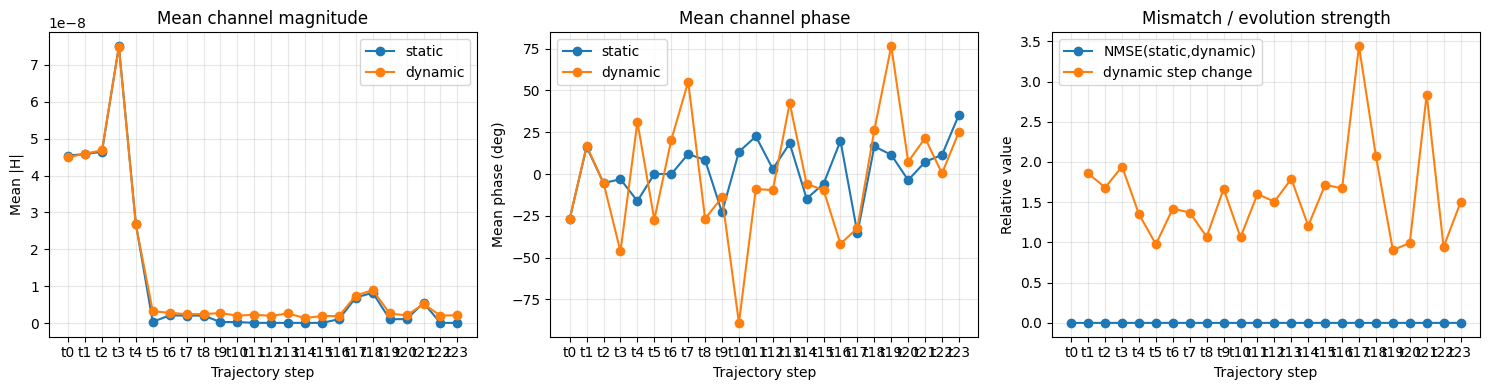

In [151]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(evolution_df['step_name'], evolution_df['static_mean_mag'], marker='o', label='static')
axes[0].plot(evolution_df['step_name'], evolution_df['dynamic_mean_mag'], marker='o', label='dynamic')
axes[0].set_title('Mean channel magnitude')
axes[0].set_xlabel('Trajectory step')
axes[0].set_ylabel('Mean |H|')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(evolution_df['step_name'], evolution_df['static_mean_phase_deg'], marker='o', label='static')
axes[1].plot(evolution_df['step_name'], evolution_df['dynamic_mean_phase_deg'], marker='o', label='dynamic')
axes[1].set_title('Mean channel phase')
axes[1].set_xlabel('Trajectory step')
axes[1].set_ylabel('Mean phase (deg)')
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(evolution_df['step_name'], evolution_df['nmse_static_vs_dynamic'], marker='o', label='NMSE(static,dynamic)')
axes[2].plot(evolution_df['step_name'], evolution_df['fro_change_from_prev_dynamic'], marker='o', label='dynamic step change')
axes[2].set_title('Mismatch / evolution strength')
axes[2].set_xlabel('Trajectory step')
axes[2].set_ylabel('Relative value')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


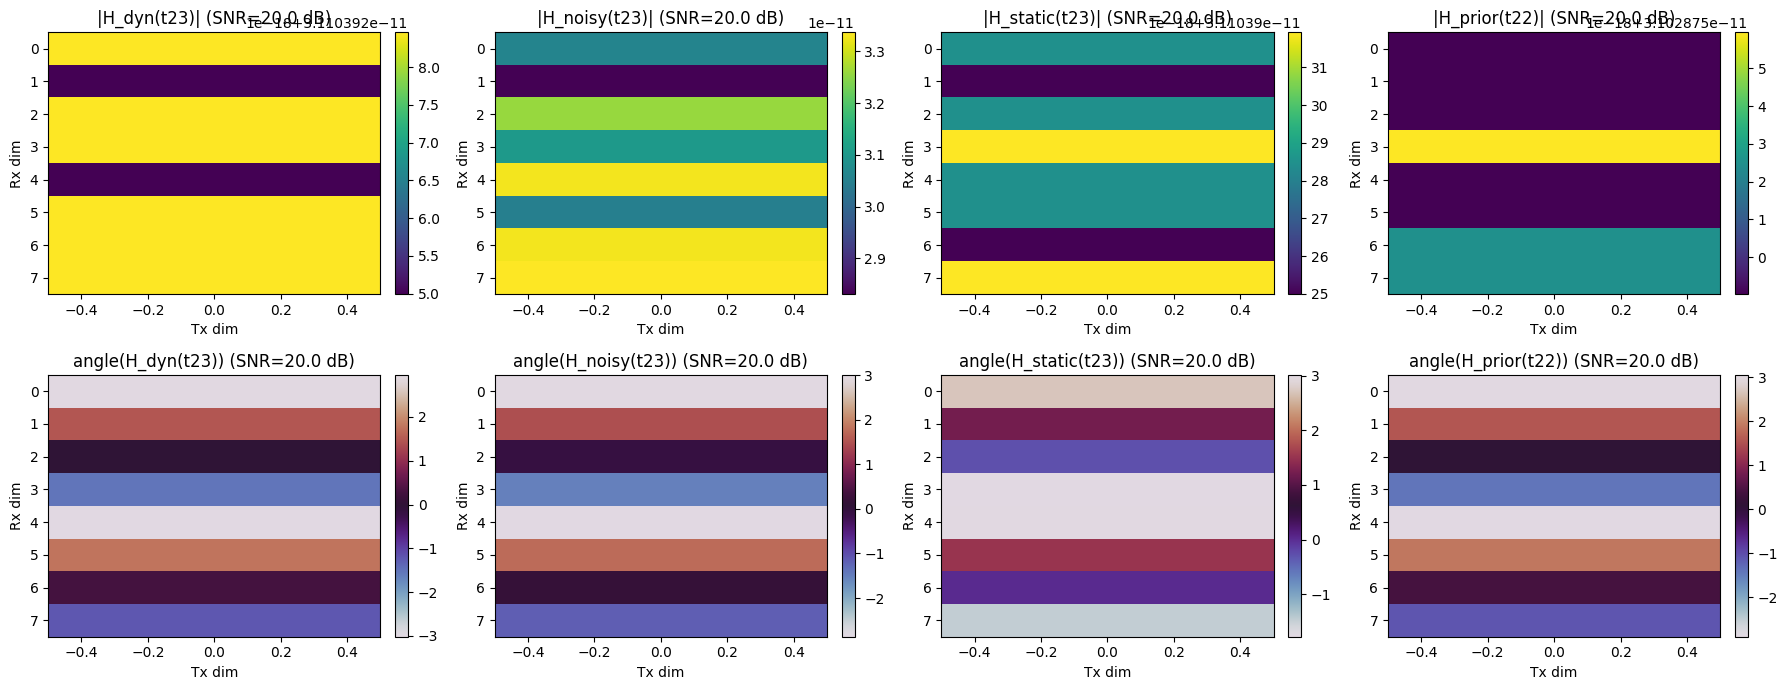

In [133]:
def plot_channel_quad(H_dynamic, H_noisy, H_static, H_prior, final_label='c', prior_label='b', title_suffix=''):
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))

    mats = [
        (np.abs(H_dynamic), f'|H_dyn({final_label})| {title_suffix}', 'viridis'),
        (np.abs(H_noisy), f'|H_noisy({final_label})| {title_suffix}', 'viridis'),
        (np.abs(H_static), f'|H_static({final_label})| {title_suffix}', 'viridis'),
        (np.abs(H_prior), f'|H_prior({prior_label})| {title_suffix}', 'viridis'),
        (np.angle(H_dynamic), f'angle(H_dyn({final_label})) {title_suffix}', 'twilight'),
        (np.angle(H_noisy), f'angle(H_noisy({final_label})) {title_suffix}', 'twilight'),
        (np.angle(H_static), f'angle(H_static({final_label})) {title_suffix}', 'twilight'),
        (np.angle(H_prior), f'angle(H_prior({prior_label})) {title_suffix}', 'twilight'),
    ]

    for ax, (mat, title, cmap) in zip(axes.flat, mats):
        im = ax.imshow(mat, aspect='auto', cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel('Tx dim')
        ax.set_ylabel('Rx dim')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


plot_channel_quad(
    H_final_dynamic,
    H_noisy_dynamic,
    H_final_static,
    H_prior_from_prev,
    final_label=final_label,
    prior_label=prev_label,
    title_suffix=f'(SNR={NOISY_OBS_SNR_DB:.1f} dB)',
)


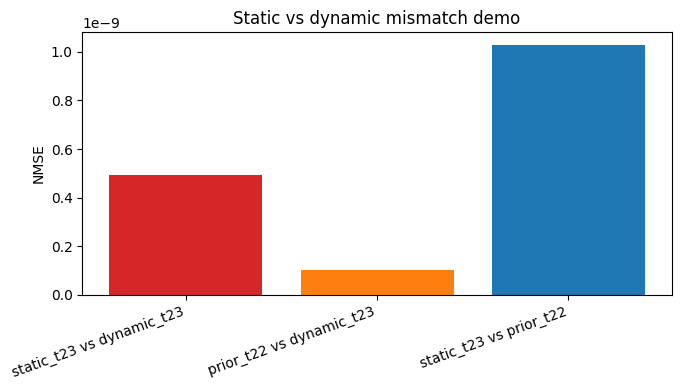

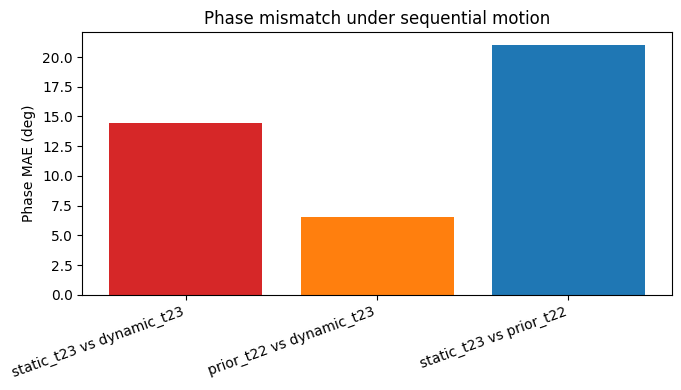

In [132]:
plt.figure(figsize=(7, 4))
plt.bar(metrics['comparison'], metrics['nmse'], color=['tab:red', 'tab:orange', 'tab:blue'])
plt.ylabel('NMSE')
plt.title('Static vs dynamic mismatch demo')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(metrics['comparison'], metrics['phase_mae_deg'], color=['tab:red', 'tab:orange', 'tab:blue'])
plt.ylabel('Phase MAE (deg)')
plt.title('Phase mismatch under sequential motion')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


## Takeaway

This notebook is only a minimal illustration, but it makes the key point:

- If you care about **dynamic instantaneous CSI**, a static prior at the final geometry is not the same as the true time-evolved channel.
- A stale or quasi-static prior can still be useful, but it is no longer an oracle.
- That is the right setup for arguing that PathFormer can support online channel estimation under mobility and Doppler.

The next step after this toy demo would be to replace the simple scalar Doppler rotation with:
- per-path Doppler
- pilot corruption / SNR control
- and a real estimator-fusion experiment with LWM / WiFo / another channel model.


In [28]:
import torch
data = torch.load("/home/blessedg/Pathformer/WiFo/dataset/blessed_task_user_loc/_city_47_chicago_3p5_train_data.pt")

In [29]:
data['channels'][0].numpy().max()

np.complex64(1.6319894-0.0071091033j)

In [31]:
# train_normalized = (data['channels'] - data['channels'].mean())/(data['channels'].std())
train_normalized.numpy().std()

np.float32(1.0000004)

In [10]:
import hdf5storage

In [13]:
wifo_data = hdf5storage.loadmat("/home/blessedg/kayley/PathFormer/wifo/D1/X_train.mat")

In [32]:
wifo_data['X_train'][0].min()

np.complex128(-2.68789895993878+0.3432363385913406j)